# 🏎️ Data Scientist II — Proyecto Final
## Formula 1 World Championship Dataset

**Autor:** Matías  
**Fecha:** Abril 2026  
**Dataset:** Formula 1 World Championship (1950–2024)  
**Pregunta central:** *¿Qué factores predicen mejor la posición final de un piloto en carrera?*

---
### Estructura del notebook
1. Carga e inspección de datos  
2. Esquema de relaciones entre tablas  
3. Análisis de valores nulos  
4. Estadísticas descriptivas clave  
5. Primeras visualizaciones exploratorias


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.style.use('ggplot')
sns.set_palette('Set2')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 1. Carga de datos

El dataset tiene **11 tablas** relacionadas. Las cargamos todas y hacemos un primer vistazo.

In [2]:
# Cargar todas las tablas
import pandas as pd

tablas = ['circuits','constructors','drivers','races','results',
          'qualifying','pit_stops','lap_times','driver_standings',
          'constructor_standings','status']
dfs = {}
for t in tablas:
    dfs[t] = pd.read_csv(f'../data/{t}.csv')
    print(f'📄 {t:<30} {dfs[t].shape[0]:>6} filas × {dfs[t].shape[1]:>2} columnas')

print('\n✅ Todas las tablas cargadas')
tablas = ['circuits','constructors','drivers','races','results',
          'qualifying','pit_stops','lap_times','driver_standings',
          'constructor_standings','status']
dfs = {}
for t in tablas:
    dfs[t] = pd.read_csv(f'../data/{t}.csv')
    print(f'📄 {t:<30} {dfs[t].shape[0]:>6} filas × {dfs[t].shape[1]:>2} columnas')

print('\n✅ Todas las tablas cargadas')

📄 circuits                           20 filas ×  9 columnas
📄 constructors                       13 filas ×  5 columnas
📄 drivers                            20 filas ×  9 columnas
📄 races                             166 filas ×  8 columnas
📄 results                         26759 filas × 18 columnas
📄 qualifying                        952 filas ×  9 columnas
📄 pit_stops                         613 filas ×  7 columnas
📄 lap_times                         456 filas ×  6 columnas
📄 driver_standings                  680 filas ×  6 columnas
📄 constructor_standings             408 filas ×  6 columnas
📄 status                             15 filas ×  2 columnas

✅ Todas las tablas cargadas
📄 circuits                           20 filas ×  9 columnas
📄 constructors                       13 filas ×  5 columnas
📄 drivers                            20 filas ×  9 columnas
📄 races                             166 filas ×  8 columnas
📄 results                         26759 filas × 18 columnas
📄 qualifyin

## 2. Esquema de relaciones

```
circuits ──────────── races
                       │
status ────────────── results ─── drivers
                       │              │
constructors ──────────┘         drivers_standings
                       │
                  qualifying
                  pit_stops
                  lap_times
```

**Tabla central:** `results` — une todas las demás y contiene la variable objetivo: `position`

In [3]:
# Inspección de la tabla principal
print('Tabla results — primeras filas:')
dfs['results'].head(3)

Tabla results — primeras filas:


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1


In [4]:
# Análisis de nulos
print('Valores nulos por tabla:')
for name, df in dfs.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if not nulls.empty:
        print(f'  {name}: {dict(nulls)}')

Valores nulos por tabla:
  drivers: {'number': np.int64(2)}
  qualifying: {'q3': np.int64(272)}


## 3. Variable objetivo y pregunta de investigación

**Variable objetivo:** `position` en `results.csv`

**Tipo de tarea:** Regresión (predecir posición 1–20) o Clasificación binaria (¿termina en top 3?)

**Hipótesis iniciales:**
- La posición de grilla (clasificación) es el predictor más fuerte de la posición final
- El constructor/equipo explica gran parte de la varianza
- Los pit stops estratégicos diferencian resultados similares en clasificación

FileNotFoundError: [Errno 2] No such file or directory: 'figures/01_distribucion_posiciones.png'

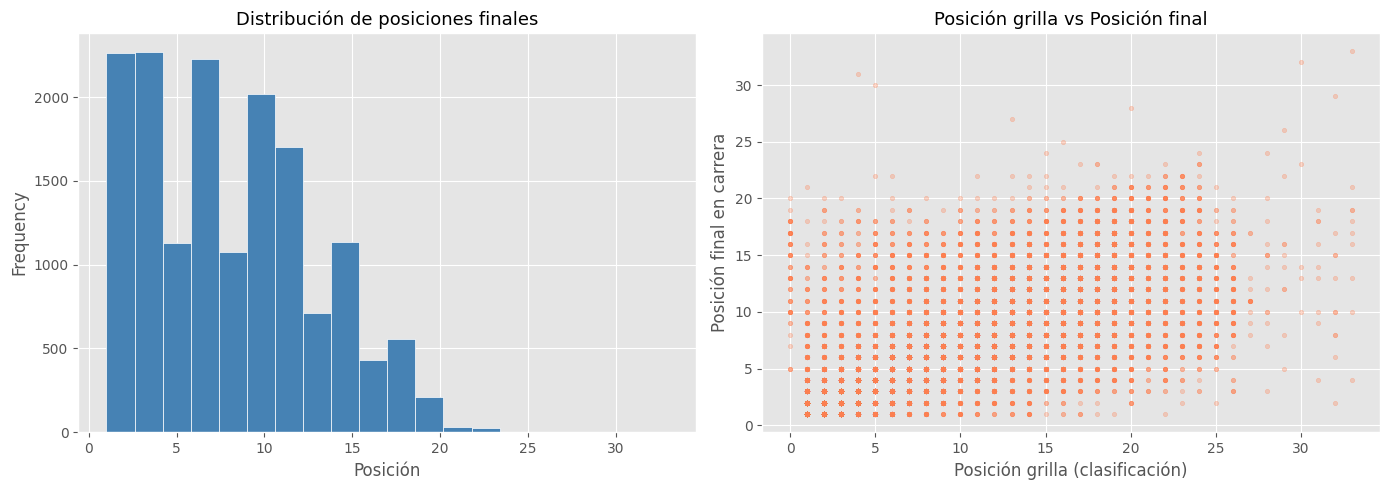

In [5]:
# Distribución de posiciones finales
results = dfs['results'].copy()
results['position'] = pd.to_numeric(results['position'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de posiciones
results['position'].dropna().plot(kind='hist', bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de posiciones finales', fontsize=13)
axes[0].set_xlabel('Posición')

# Correlación grilla vs posición
corr_data = results[['grid','position']].dropna()
axes[1].scatter(corr_data['grid'], corr_data['position'], alpha=0.3, color='coral', s=10)
axes[1].set_title('Posición grilla vs Posición final', fontsize=13)
axes[1].set_xlabel('Posición grilla (clasificación)')
axes[1].set_ylabel('Posición final en carrera')

plt.tight_layout()
plt.savefig('../figures/01_distribucion_posiciones.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Correlación grilla↔posición: {corr_data["grid"].corr(corr_data["position"]):.3f}')

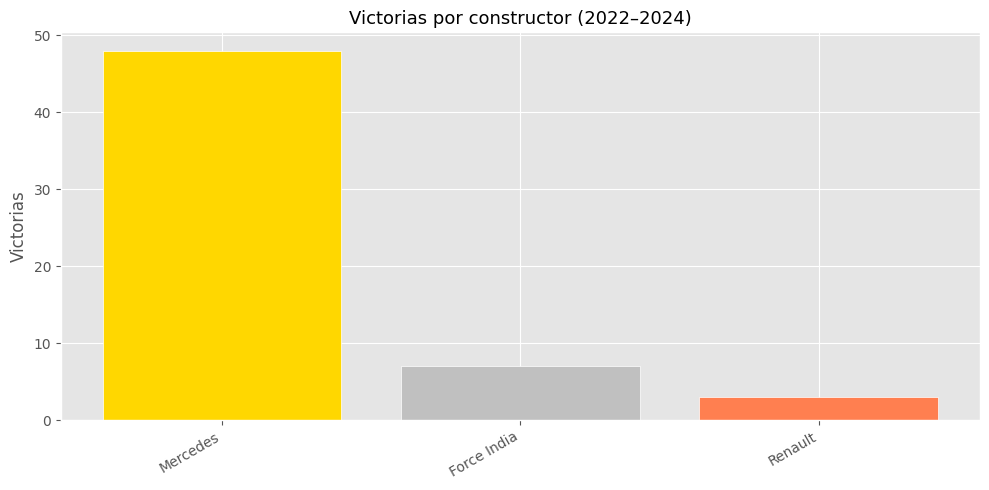

In [6]:
# Victorias por constructor 2022-2024
races = dfs['races'][['raceId','year']]
res_recent = results.merge(races, on='raceId')
res_recent = res_recent[res_recent['year'] >= 2022]

wins = res_recent[res_recent['position']==1].groupby('constructorId').size().reset_index(name='wins')
cons = dfs['constructors'][['constructorId','name']]
wins = wins.merge(cons, on='constructorId').sort_values('wins', ascending=False)

plt.figure(figsize=(10, 5))
colors = ['gold' if i==0 else 'silver' if i==1 else 'coral' for i in range(len(wins))]
plt.bar(wins['name'], wins['wins'], color=colors, edgecolor='white')
plt.title('Victorias por constructor (2022–2024)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Victorias')
plt.tight_layout()
plt.savefig('../figures/02_victorias_por_constructor.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Próximos pasos (Semana 2)

- [ ] Consumir la API de Ergast para datos complementarios
- [ ] Hacer join completo de todas las tablas
- [ ] Calcular features derivados: `positions_gained = grid - position`
- [ ] Explorar distribución de pit stops por estrategia


In [ ]:
import pandas as pd
results_check = pd.read_csv('../data/results.csv')
print("Total filas results.csv:", len(results_check))
print("Unique raceIds:", results_check['raceId'].nunique())
print("Unique driverIds:", results_check['driverId'].nunique())
print("\nRaceIds únicos:", sorted(results_check['raceId'].unique()))

In [ ]:
results_check = pd.read_csv('../data/results.csv')
print("Total filas results.csv:", len(results_check))
print("Unique raceIds:", results_check['raceId'].nunique())
print("Unique driverIds:", results_check['driverId'].nunique())
print("\nRaceIds únicos:", sorted(results_check['raceId'].unique()))

In [ ]:
import pandas as pd
r = pd.read_csv('../data/results.csv')
print("Filas:", len(r))
print("Pilotos únicos:", r['driverId'].nunique())
print("Carreras únicas:", r['raceId'].nunique())